In [1]:
!pip install gymnasium==0.29.0

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import defaultdict
import tensorflow as tf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.8/953.8 kB 51.0 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.2.2
    Uninstalling gymnasium-1.2.2:
      Successfully uninstalled gymnasium-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.


In [ ]:
env = gym.make("Blackjack-v1", sab=True)  # Sutton & Barto variant
n_actions = env.action_space.n            # 2 actions: 0=stick, 1=hit

print("Action space:", env.action_space)
print("Observation space:", env.observation_space) #player sum, dealer card, usable ace,


Action space: Discrete(2)
Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))


In [ ]:
def run_episode_with_policy(env, policy, seed=None):
    """
    Run a single episode using a given policy (function: obs -> action).
    Returns the final reward.
    """
    obs, info = env.reset(seed=seed) #obs is (player sum, dealer card, usable ace), info is {}
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = policy(obs)
        obs, reward, terminated, truncated, info = env.step(action)

    return reward

def evaluate_policy(env, policy, n_episodes=1000, seed=None):
    """
    Evaluate a policy over n_episodes.
    Returns: (win_rate, loss_rate, draw_rate)
    where win = reward>0, loss = reward<0, draw = 0.
    """
    wins = 0
    losses = 0
    draws = 0

    rng = np.random.default_rng(seed)

    for _ in range(n_episodes):
        episode_seed = int(rng.integers(0, 1e9))
        r = run_episode_with_policy(env, policy, seed=episode_seed)
        if r > 0:
            wins += 1
        elif r < 0:
            losses += 1
        else:
            draws += 1

    total = n_episodes
    return wins / total, losses / total, draws / total


In [ ]:
def basic_policy(obs):
    """
    obs = (player_sum, dealer_card, usable_ace)
    Stick if player_sum >= 17, else hit.
    """
    player_sum, dealer_card, usable_ace = obs
    return 0 if player_sum >= 17 else 1  # 0 = stick, 1 = hit

wins, loses, draws = evaluate_policy(env, basic_policy, n_episodes=1000, seed=42)
print("Baseline 17+ policy over 1000 games:")
print("win rate: ", wins)
print("loss rate: ", loses)
print("draw rate: ", draws)


Baseline 17+ policy over 1000 games:
win rate:  0.4
loss rate:  0.497
draw rate:  0.103


In [ ]:
# Build Q-table shape directly from observation space
obs_space = env.observation_space # player sum: 32, dealer card: 11, usable ace: 2 
obs_dims = [space.n for space in obs_space]  # [32, 11, 2]
q_shape = tuple(obs_dims) + (n_actions,) # (32, 11, 2, 2)

Q = np.zeros(q_shape, dtype=np.float32)

# Hyperparameters
alpha = 0.05      # learning rate controls how much new info overrides old information
gamma = 0.99      # discount factor How much the agent values future rewards vs immediate rewards
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay_episodes = 200_000

n_train_episodes = 300_000


In [ ]:
def epsilon_greedy_policy(obs, Q, epsilon):
    """
    obs: (player_sum, dealer_card, usable_ace)
    """
    ps, dc, ua = obs
    if np.random.rand() < epsilon: # generate random number in [0.0, 1.0)
        return np.random.randint(n_actions) # explore: random action either 0 or 1
    return int(np.argmax(Q[ps, dc, ua])) # return action with highest Q-value


In [ ]:
train_win_rates = []
train_window = 5000  # moving window size for win-rate estimate

episode_rewards = np.zeros(n_train_episodes, dtype=np.float32)  #Pre-allocate array to store the reward (+1, 0, or -1) from each episode

for episode in range(n_train_episodes):
    # Compute epsilon (linear decay)
    if episode < epsilon_decay_episodes:
        epsilon = epsilon_start - (epsilon_start - epsilon_end) * (episode / epsilon_decay_episodes) # adjust epsilon linearly
    else:
        epsilon = epsilon_end

    obs, info = env.reset()
    terminated = False
    truncated = False

    total_reward = 0.0

    while not (terminated or truncated):
        ps, dc, ua = obs
        action = epsilon_greedy_policy(obs, Q, epsilon)

        next_obs, reward, terminated, truncated, info = env.step(action)
        nps, ndc, nua = next_obs # next player sum, next dealer card, next usable ace

        # Q-learning update
        best_next_Q = 0.0
        if not (terminated or truncated):
            best_next_Q = np.max(Q[nps, ndc, nua]) # get value with highest Q-value based on next observation

        td_target = reward + gamma * best_next_Q # what q value should be
        td_error = td_target - Q[ps, dc, ua, action] # how wrong is the current estimation is 
        Q[ps, dc, ua, action] += alpha * td_error  # update Q-value with learning rate alpha

        obs = next_obs
        total_reward += reward

    episode_rewards[episode] = total_reward

    # track moving win rate (reward > 0 counts as win)
    if episode >= train_window:
        window = episode_rewards[episode - train_window + 1 : episode + 1]
        win_rate = np.mean(window > 0)
        train_win_rates.append(win_rate)

    if (episode + 1) % 50_000 == 0:
        print(f"Episode {episode + 1}/{n_train_episodes} | epsilon={epsilon}")


Episode 50000/300000 | epsilon=0.76250475
Episode 100000/300000 | epsilon=0.52500475
Episode 150000/300000 | epsilon=0.2875047500000001
Episode 200000/300000 | epsilon=0.05000475000000004
Episode 250000/300000 | epsilon=0.05
Episode 300000/300000 | epsilon=0.05


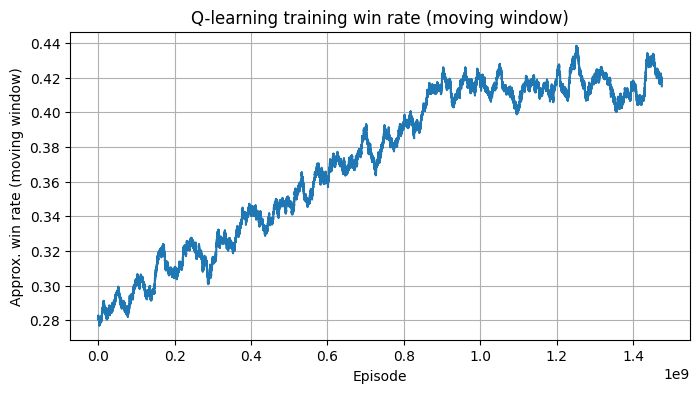

In [9]:
plt.figure(figsize=(8,4))
plt.plot(np.arange(len(train_win_rates)) * train_window, train_win_rates)
plt.xlabel("Episode")
plt.ylabel("Approx. win rate (moving window)")
plt.title("Q-learning training win rate (moving window)")
plt.grid(True)
plt.show()


In [ ]:
def q_greedy_policy(obs):
    """
    greedy policy from the learned Q-table.
    """
    ps, dc, ua = obs
    return int(np.argmax(Q[ps, dc, ua])) # return index with highest Q-value


In [13]:
wins_q, losses_q, draws_q = evaluate_policy(env, q_greedy_policy, n_episodes=1000, seed=123)

print("Q-learning policy over 1000 evaluation games:")
print("win rate:", wins_q)
print("loss rate:", losses_q)
print("draw rate:", draws_q)

print("\nComparison vs baseline (17+ stick):")
print("baseline win rate :", wins)
print("q-learning win rate:", wins_q)

Q-learning policy over 1000 evaluation games:
win rate: 0.441
loss rate: 0.461
draw rate: 0.098

Comparison vs baseline (17+ stick):
baseline win rate : 0.4
q-learning win rate: 0.441


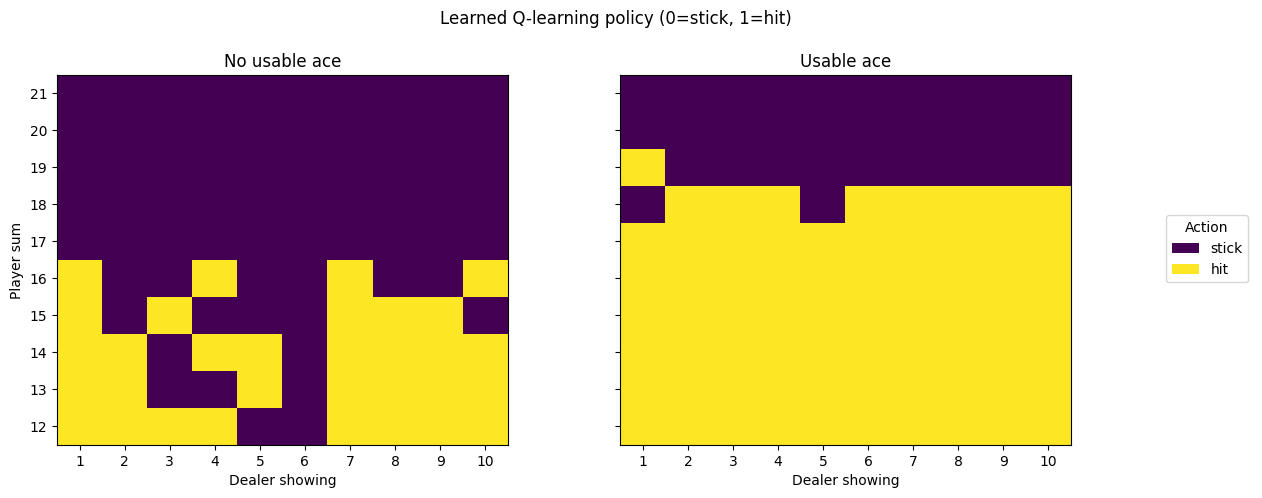

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def extract_policy_matrix(Q, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)
    policy_mat = np.zeros((len(player_sums), len(dealer_cards)), dtype=int)

    for i, ps in enumerate(player_sums):
        for j, dc in enumerate(dealer_cards):
            policy_mat[i, j] = np.argmax(Q[ps, dc, usable_ace])

    return player_sums, dealer_cards, policy_mat


player_sums, dealer_cards, policy_no_ace = extract_policy_matrix(Q, usable_ace=0)
_, _, policy_ace = extract_policy_matrix(Q, usable_ace=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

titles = ["No usable ace", "Usable ace"]
heatmaps = []

for ax, policy_mat, title in zip(axes, [policy_no_ace, policy_ace], titles):
    im = ax.imshow(policy_mat, origin="lower", aspect="auto")
    heatmaps.append(im)
    ax.set_xticks(np.arange(len(dealer_cards)))
    ax.set_xticklabels(dealer_cards)
    ax.set_yticks(np.arange(len(player_sums)))
    ax.set_yticklabels(player_sums)
    ax.set_xlabel("Dealer showing")
    ax.set_title(title)

axes[0].set_ylabel("Player sum")


cmap = heatmaps[0].cmap

legend_elements = [
    Patch(facecolor=cmap(0.0), label="stick"),
    Patch(facecolor=cmap(1.0), label="hit")
]
fig.legend(handles=legend_elements,
           title="Action",
           loc="right",
           borderaxespad=1.0)

fig.subplots_adjust(left=0.07, right=0.85, wspace=0.25, top=0.85)
fig.suptitle("Learned Q-learning policy (0=stick, 1=hit)", y=0.98)

plt.show()


In [ ]:
env.reset()

((15, 2, 1), {})

In [ ]:
output = env.action_space.n
input_shape = (3,)

In [ ]:
print(input_shape)

(3,)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation = 'elu', input_shape =input_shape),
    tf.keras.layers.Dense(50, activation = 'elu'), # elu = Exponential Linear Unit , because q values can be negative
    tf.keras.layers.Dense(25, activation = 'elu'),
    tf.keras.layers.Dense(10, activation = 'elu'),
    tf.keras.layers.Dense(output)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model(tf.zeros((1,) + input_shape)) # initialize model by passing a dummy input

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[0., 0.]], dtype=float32)>

In [ ]:

target = tf.keras.models.clone_model(model)
target.set_weights(model.get_weights())# copy weights from model to target

In [ ]:
from collections import deque
replay_buffer = deque(maxlen=2000) # double ended queue, can take from both ends

In [ ]:
def epsilon_greedy_policy(state, epsilon=0):
  # Convert the state tuple to a numpy array state is (player_sum, dealer_card, usable_ace)
  state_array = np.array(state, dtype=np.float32)
  if np.random.rand() < epsilon:
    return np.random.randint(output) # random action
  else:
    Q_values = model.predict(state_array[np.newaxis], verbose=0)[0] # (1,3)  add new axis to make it (1,3)
    return Q_values.argmax() # optimal action according to the DQN

In [ ]:
def sample_experiences(batch_size):
  indices = np.random.randint(len(replay_buffer),size = batch_size) #32 random indices
  batch = [replay_buffer[index] for index in indices] # get experiences corresponding to indices
  return [
      np.array([experience[field_index] for experience in batch])
      for field_index in range(6) # create a numpy array for each field index of the experience
  ]# [states, actions, rewards, next_states, dones, truncateds]

In [ ]:
batch_size = 32
discount_factor = 0.05
optimizer = tf.keras.optimizers.Nadam(learning_rate=1e-2)
loss_fn = tf.keras.losses.MeanSquaredError()

In [ ]:
def play_one_step(env,state,epsilon):
  action = epsilon_greedy_policy(state, epsilon) # gets random action or action from DQN
  next_state,reward,done,truncated,info = env.step(action)
  replay_buffer.append((state,action,reward,next_state,done,truncated,info))
  return next_state,reward,done,truncated,info


In [ ]:
def training_step(batch_size):
  experiences = sample_experiences(batch_size) # we get 32 random experiences
  states, actions, rewards, next_states, dones, truncateds = experiences # unpack experiences
  next_Q_values = target.predict(next_states, verbose=0)  # get Q values for each  possible action in each experience next
  max_next_Q_values = next_Q_values.max(axis=1) # get max Q value for each next state
  runs = 1.0 - (dones | truncateds) # episode is not done or truncated act as a filter to check if the game ended or not
  target_Q_values = rewards + runs * discount_factor * max_next_Q_values # target Q value calculation
  target_Q_values = target_Q_values.reshape(-1, 1) 
  mask = tf.one_hot(actions, output)
  with tf.GradientTape() as tape: # record operations for automatic differentiation
    all_Q_values = model(states) # get Q values for all actions
    Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True) # eliminates  values for actions we didnt take
    loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values)) # 
  grads = tape.gradient(loss, model.trainable_variables) # calculates how much each weight contributed to the loss
  optimizer.apply_gradients(zip(grads, model.trainable_variables)) #updates the weights using gradients so as to minimize the loss for next time

  print(f"  Batch Loss: {loss.numpy():.4f}")

In [ ]:
for episode in range(1000):
  obs_tuple, info = env.reset() # start new episode
  obs_dqn_input = np.array(obs_tuple, dtype=np.float32) # Convert obs tuple to numpy array

  for step in range(300):
    epsilon = max(1 - episode / 500, 0.01) # decay epsilon over episodes
    next_obs_tuple, reward, done, truncated, info = play_one_step(env, obs_dqn_input, epsilon) # play one step at the time
    obs_dqn_input = np.array(next_obs_tuple, dtype=np.float32) # Convert next_obs tuple to numpy array for the next step

    if done or truncated:
      break
    if episode > 50: # start training after some experiences are collected
      training_step(batch_size)
    if episode % 50 == 0:
      target.set_weights(model.get_weights())

  Batch Loss: 3.0676
  Batch Loss: 2.2685
  Batch Loss: 4.1888
  Batch Loss: 4.7694
  Batch Loss: 0.7137
  Batch Loss: 0.6719
  Batch Loss: 0.6730
  Batch Loss: 0.5622
  Batch Loss: 0.5198
  Batch Loss: 0.4472
  Batch Loss: 0.5846
  Batch Loss: 0.6496
  Batch Loss: 0.7831
  Batch Loss: 0.6753
  Batch Loss: 0.5367
  Batch Loss: 0.4938
  Batch Loss: 0.4384
  Batch Loss: 0.5877
  Batch Loss: 0.5976
  Batch Loss: 0.3408
  Batch Loss: 0.4905
  Batch Loss: 0.4927
  Batch Loss: 0.5830
  Batch Loss: 0.5516
  Batch Loss: 0.5341
  Batch Loss: 0.5909
  Batch Loss: 0.3703
  Batch Loss: 0.6835
  Batch Loss: 0.4572
  Batch Loss: 0.4976
  Batch Loss: 0.5762
  Batch Loss: 0.5962
  Batch Loss: 0.4473
  Batch Loss: 0.6651
  Batch Loss: 0.5959
  Batch Loss: 0.4849
  Batch Loss: 0.5969
  Batch Loss: 0.6046
  Batch Loss: 0.6082
  Batch Loss: 0.4813
  Batch Loss: 0.7463
  Batch Loss: 0.6945
  Batch Loss: 0.6116
  Batch Loss: 0.3482
  Batch Loss: 0.3402
  Batch Loss: 0.4707
  Batch Loss: 0.6153
  Batch Loss:

In [ ]:
wins_dqn, losses_dqn, draws_dqn = evaluate_policy(env, epsilon_greedy_policy, n_episodes=1000, seed=456)

print("DQN policy over 1000 evaluation games:")
print("win rate:", wins_dqn)
print("loss rate:", losses_dqn)
print("draw rate:", draws_dqn)

print("\nComparison vs Q-learning:")
print("Q-learning win rate:", wins_q)
print("DQN win rate:", wins_dqn)

DQN policy over 1000 evaluation games:
win rate: 0.449
loss rate: 0.469
draw rate: 0.082

Comparison vs Q-learning:
Q-learning win rate: 0.429
DQN win rate: 0.449
